In [24]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.tree import plot_tree

# Load dataset
df = pd.read_csv("Titanic-Dataset.csv")

# Define target (y) and features (X)
# Target variable: Survived (0 = No, 1 = Yes)
y = df["Survived"]

# Drop columns that are either identifiers or high-cardinality text columns.
X = df.drop(columns=["Survived", "PassengerId", "Name", "Ticket", "Cabin"])

# Identify numeric and categorical columns
# These are the remaining columns in X typically:
# Pclass (int), Sex (cat), Age (float), SibSp (int), Parch (int),
# Fare (float), Embarked (cat)
numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Sex", "Embarked"]

# Build preprocessing pipelines
# Numeric preprocessing:
# - Fill missing numeric values using the median (fit on TRAIN ONLY)
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing:
# - Fill missing categorical values using the most frequent (mode) (fit on TRAIN ONLY)
# - One-hot encode categories (fit on TRAIN ONLY)
#   handle_unknown="ignore" prevents errors if test has unseen categories.
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer applies the right preprocessing to each column group
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"  # explicitly drop anything not listed
)

# Build the full model pipeline
# Pipeline ensures preprocessing happens inside CV folds correctly.
# This is the proper way to avoid leakage during RandomizedSearchCV.
model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("rf", RandomForestClassifier(random_state=42))
])

In [25]:
# Train-test split
# Use stratify=y to keep survival ratio similar in train and test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Hyperparameter tuning setup (RandomizedSearchCV)
# Note: When using Pipeline, parameters must be prefixed with the step name "rf__"
param_dist = {
    "rf__n_estimators": [100, 200, 300],
    "rf__max_depth": [5, 10, None],
    "rf__min_samples_split": [2, 4, 6],
    "rf__min_samples_leaf": [1, 2, 3],
    "rf__max_features": ["sqrt", "log2"],
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=15,               # number of random combinations to try
    cv=3,                    # 3-fold cross-validation
    scoring="accuracy",      # optimize for accuracy
    n_jobs=-1,               # use all CPU cores
    random_state=42,
    verbose=1
)

# Fit model + search best hyperparameters
# Preprocessing is fit on training folds only, preventing leakage.
random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

print("Best parameters (RandomizedSearchCV):", random_search.best_params_)
print("Best cross-validated accuracy (RandomizedSearchCV):", random_search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'rf__max_depth': [5, 10, ...], 'rf__max_features': ['sqrt', 'log2'], 'rf__min_samples_leaf': [1, 2, ...], 'rf__min_samples_split': [2, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies tha

Best parameters (RandomizedSearchCV): {'rf__n_estimators': 200, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_features': 'sqrt', 'rf__max_depth': 10}
Best cross-validated accuracy (RandomizedSearchCV): 0.8298417564721913


Test Accuracy: 0.8059701492537313
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.89      0.85       165
           1       0.79      0.67      0.73       103

    accuracy                           0.81       268
   macro avg       0.80      0.78      0.79       268
weighted avg       0.80      0.81      0.80       268



<Figure size 500x400 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Titanic Classification Confusion Matrix')

Text(0.5, 14.722222222222216, 'Predicted')

Text(33.22222222222222, 0.5, 'Actual')

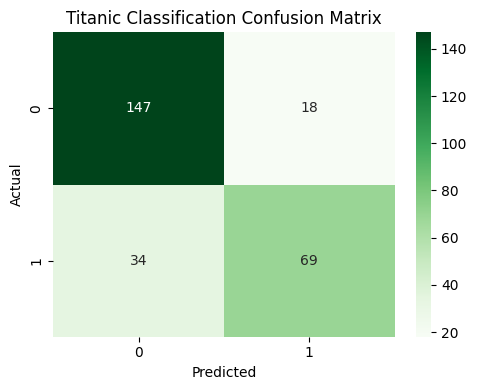

In [26]:
# Evaluate on the held-out test set
y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix values
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Titanic Classification Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

<BarContainer object of 10 artists>

([<matplotlib.axis.XTick at 0x11e346ad0>,
 [Text(0, 0, 'Fare'),
  Text(1, 0, 'Age'),
  Text(2, 0, 'Sex_male'),
  Text(3, 0, 'Sex_female'),
  Text(4, 0, 'Pclass'),
  Text(5, 0, 'SibSp'),
  Text(6, 0, 'Parch'),
  Text(7, 0, 'Embarked_S'),
  Text(8, 0, 'Embarked_C'),
  Text(9, 0, 'Embarked_Q')])

Text(0.5, 1.0, 'Feature Importances (Titanic Random Forest)')

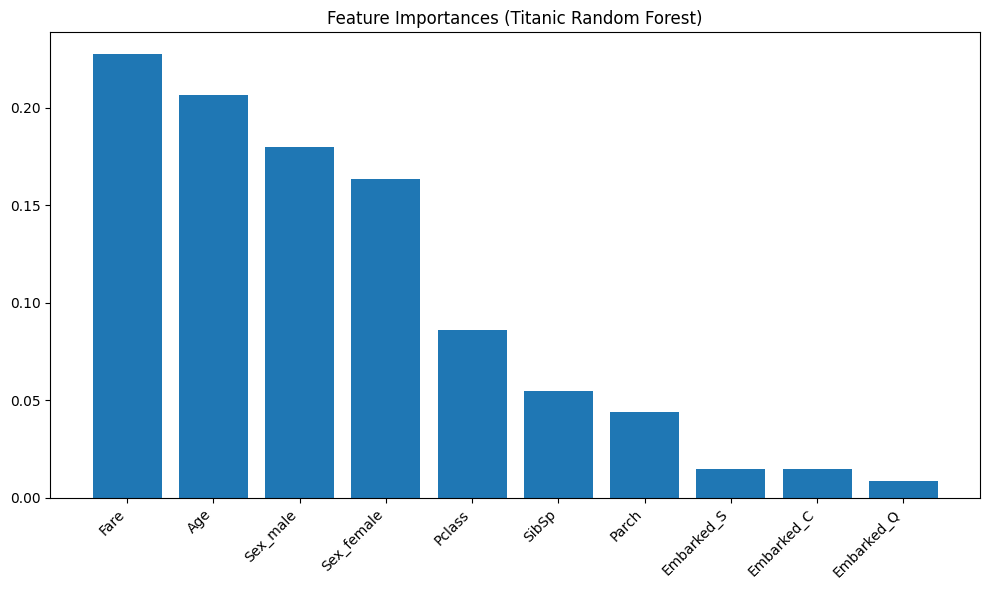

In [27]:
# Feature importance (with names)
# Because we used OneHotEncoder, the feature space expands.
# We need to extract the post-transform feature names.

# Get the preprocessor from the best pipeline
best_preprocessor = best_model.named_steps["preprocess"]

# Get numeric feature names (unchanged)
num_feature_names = numeric_features

# Get one-hot encoded categorical feature names
# We must access the OneHotEncoder inside the categorical pipeline.
ohe = best_preprocessor.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = list(ohe.get_feature_names_out(categorical_features))

# Combine final feature names (order matches ColumnTransformer output)
final_feature_names = num_feature_names + cat_feature_names

# Extract trained RandomForest model
rf_best = best_model.named_steps["rf"]

# Get feature importances and sort them
importances = rf_best.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(
    range(len(importances)),
    [final_feature_names[i] for i in indices],
    rotation=45,
    ha="right"
)
plt.title("Feature Importances (Titanic Random Forest)")
plt.tight_layout()
plt.show()

<Figure size 2200x1000 with 0 Axes>

[Text(0.5, 0.875, 'Fare <= 15.621\ngini = 0.467\nsamples = 397\nvalue = [392, 231]'),
 Text(0.25, 0.625, 'Sex_male <= 0.5\ngini = 0.34\nsamples = 220\nvalue = [274, 76]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Fare <= 13.977\ngini = 0.471\nsamples = 54\nvalue = [30.0, 49.0]'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'Age <= 11.0\ngini = 0.179\nsamples = 166\nvalue = [244, 27]'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'Age <= 25.0\ngini = 0.491\nsamples = 177\nvalue = [118, 155]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Pclass <= 2.5\ngini = 0.343\nsamples = 58\nvalue = [18, 64]'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'Parch <= 2.5\ngini = 0.499\nsamples = 119\nvalue = [100, 91]'),
 Text(0.8125, 0.125, '\n  (...)  \n'),
 Text(0.9375, 0.125, '\n  (...)  \n')]

Text(0.5, 1.0, 'Titanic Random Forest: Example Tree (Root Feature = Fare)')

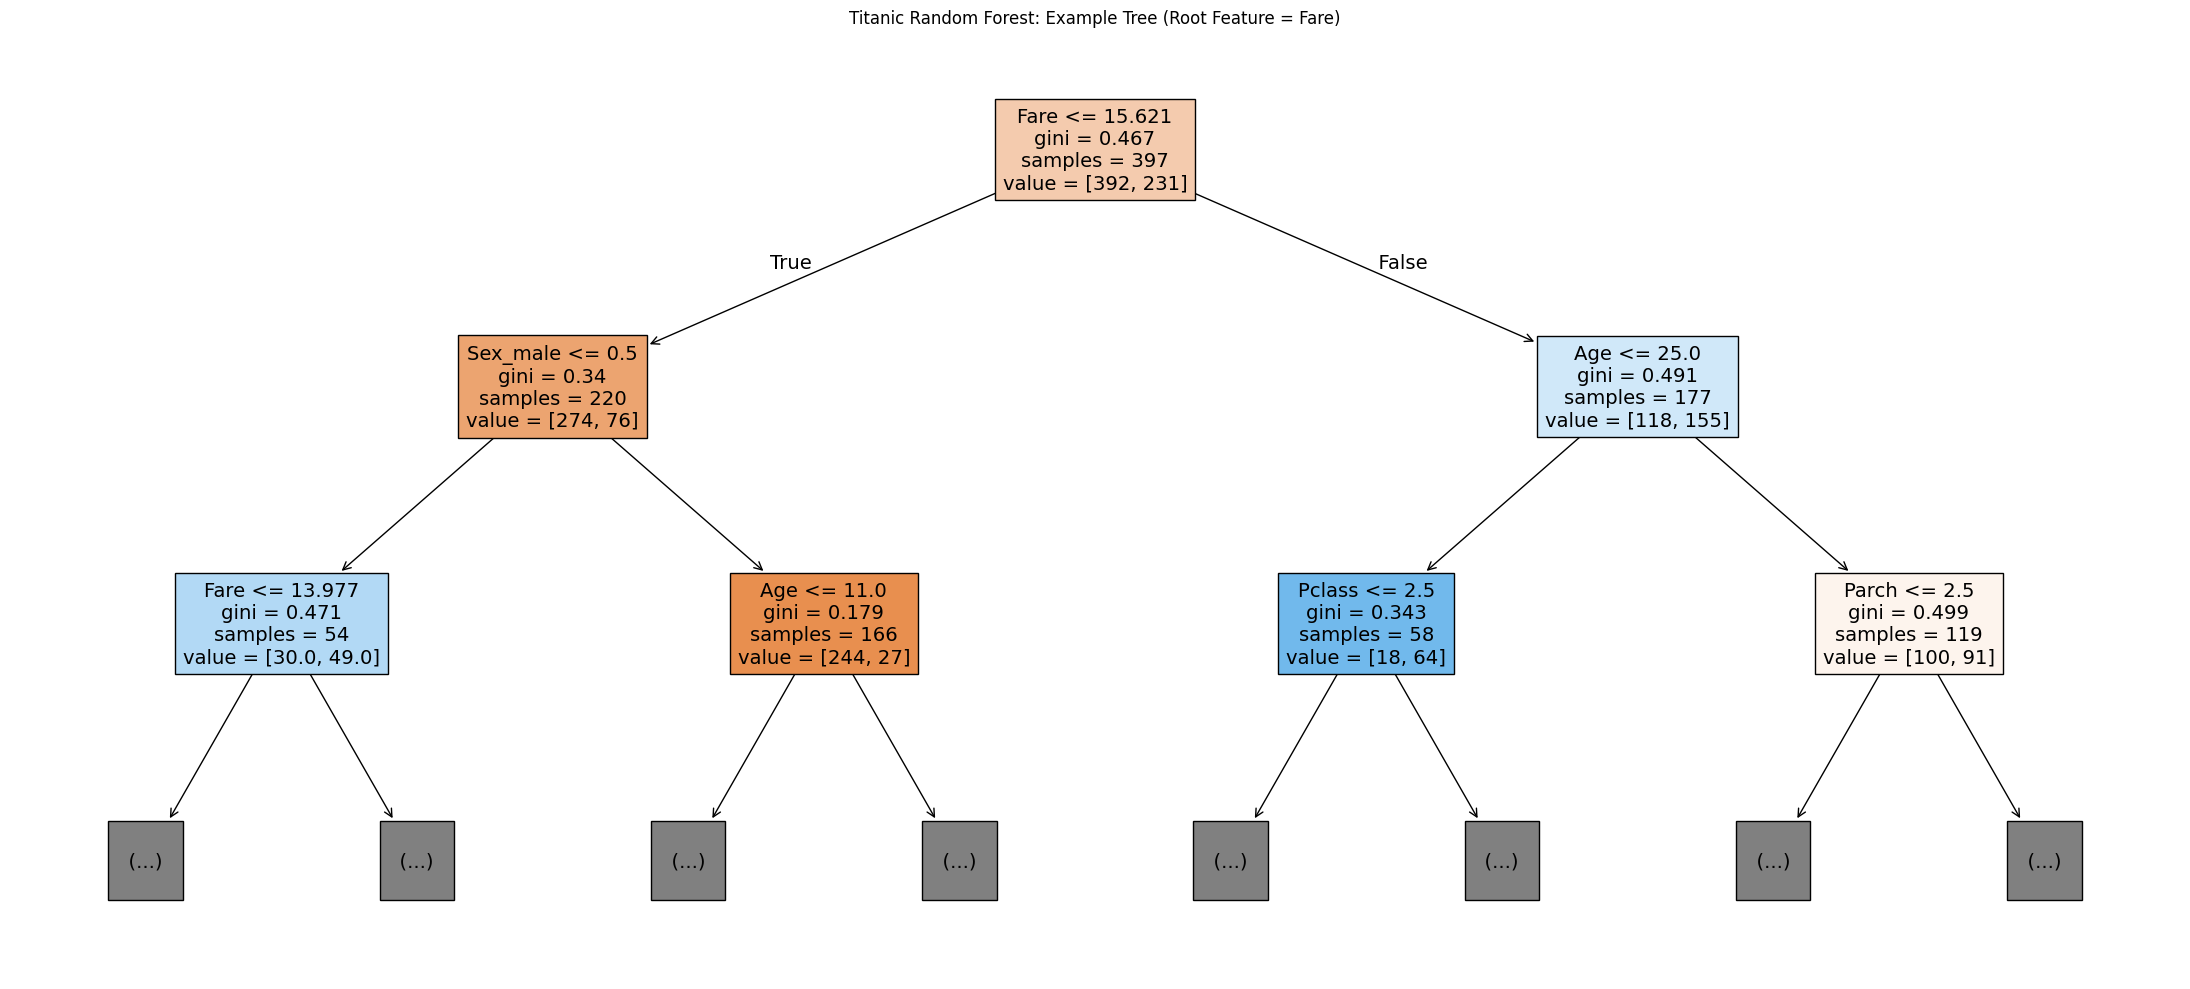

In [28]:
# Visualize one example tree (optional, interpretability)
# Pick a tree whose root split uses the most important feature (if possible)
root_feature_index = indices[0]  # index of most important feature

# In each decision tree, features are referenced by their index in final_feature_names.
tree_idx = 0
for i, est in enumerate(rf_best.estimators_):
    # est.tree_.feature[0] is the root node's splitting feature index
    if est.tree_.feature[0] == root_feature_index:
        tree_idx = i
        break

plt.figure(figsize=(22, 10))
plot_tree(
    rf_best.estimators_[tree_idx],
    feature_names=final_feature_names,
    filled=True,
    max_depth=2  # limit depth to keep the plot readable
)
plt.title(f"Titanic Random Forest: Example Tree (Root Feature = {final_feature_names[root_feature_index]})")
plt.tight_layout()
plt.show()